# Loan Risk Classification
## Data Analytics project 25/26

**Models link** Models ['https://drive.google.com/file/d/1KJyh0enu0utSTqYFNocyjgCjIBUhFqFb/view?usp=sharing']

**Structure:**
- `config.py`: paths, seed, device
- `data_processing.py`: feature engineering, ML & DL preprocessors
- `models.py`: FFNN, TabNet, TabTransformer, training loop, evaluation
- `ml_pipeline.py`: RF, KNN, SVM grid search wrappers

## 0. Setup & Imports

In [1]:
import sys
import os

sys.path.insert(0, os.path.join(os.getcwd(), "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import pickle

from config import SEED, DEVICE, MODEL_DIR, TRAIN_CSV, fix_random
from data_processing import (
    load_data,
    feature_engineer,
    #build_ml_preprocessor,
    prepare_ml_data,
    #prepare_ml_data_test,
    prepare_dl_data,
    prepare_dl_data_old,
    FFNNPreprocessor,
    
)
from ml_pipeline import (
    train_random_forest,
    train_knn,
    train_svm,
    save_model,
    save_split_model,
    print_grid_results,
    plot_rf_feature_importances,
)
from models import (
    LoanDataset,
    TabularDataset,
    LoanClassifierFFNN,
    build_tabnet_classifier,
    train_tabnet,
    build_tab_transformer,
    build_ft_transformer,
    train_model,
    evaluate_model,
    plot_losses,
    plot_confusion_matrix,
    plot_feature_importances,
    get_class_weights,
    get_class_weights_dict,
    create_loaders,
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score, 
    f1_score, 
    classification_report,
)

from sklearn.decomposition import PCA
from sklearn.preprocessing import (
    RobustScaler, 
    StandardScaler, 
    MinMaxScaler
)

fix_random(SEED)
print(f"Device: {DEVICE}")

Device: mps


## 1. Data Loading & Visualization

In [2]:
df = load_data(TRAIN_CSV)
df.head()

Loaded 148301 rows  (dropped 0 duplicates)


,loan_contract_approved_amount,loan_portfolio_total_funded,investor_side_funded_amount,loan_contract_term_months,loan_contract_interest_rate,loan_payment_installments_count,borrower_profile_employment_length,borrower_housing_ownership_status,borrower_income_annual,borrower_income_verification_status,...,hardship_last_payment_amount_total,disbursement_method_type,debt_settlement_flag_indicator,debt_settlement_flag_date,settlement_status_label,settlement_date,settlement_amount_total,settlement_percentage,settlement_term_months,grade
0,12000.0,11819.212488,12000.000000,36 months,12.806304,395.66,10+ years,rent,40000.0,source verified,...,NaN,cash,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B
1,10000.0,10683.410001,10023.226279,36 months,7.890000,312.86,2 years,rent,NaN,not verified,...,NaN,cash,n,NaN,NaN,NaN,NaN,NaN,NaN,A
2,7000.0,7000.000000,5989.447426,36 months,18.558177,253.04,8 years,mortgage,120000.0,source verified,...,NaN,cash,n,NaN,NaN,NaN,NaN,NaN,NaN,D
3,35000.0,35000.000000,35000.000000,60 months,22.950000,985.67,NaN,mortgage,99588.0,verified,...,NaN,cash,n,NaN,NaN,NaN,NaN,NaN,NaN,F
4,2400.0,2437.596602,2400.000000,36 months,13.990000,82.02,2 years,rent,37000.0,source verified,...,NaN,cash,n,NaN,NaN,NaN,NaN,NaN,NaN,C


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148301 entries, 0 to 148300
Columns: 145 entries, loan_contract_approved_amount to grade
dtypes: float64(112), object(33)
memory usage: 164.1+ MB


/var/folders/c4/m_6w9kxs5kj6jyfn6b9_dsbr0000gn/T/ipykernel_69055/3926484378.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


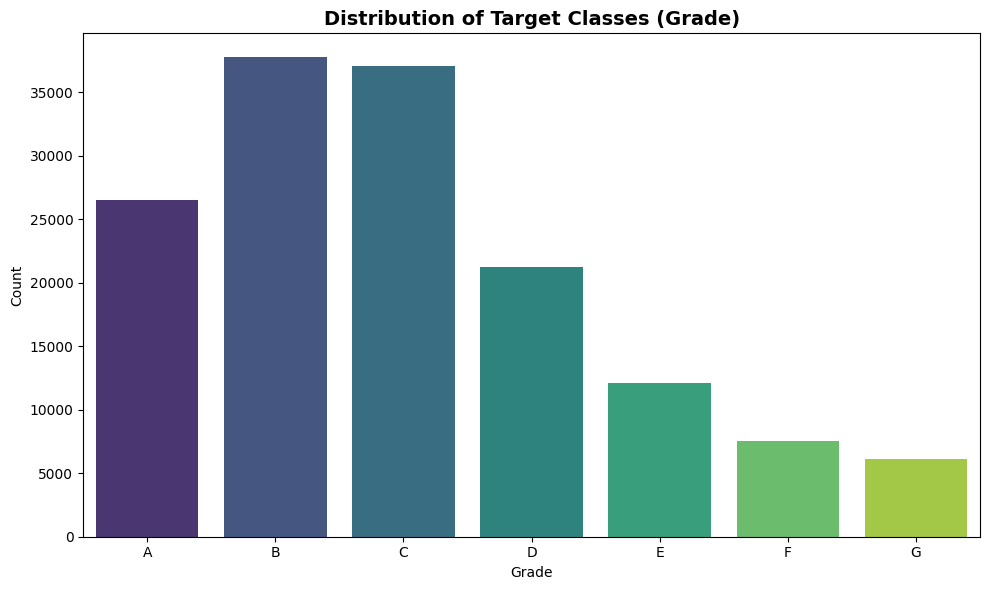

In [4]:
# Target distribution
class_counts = df["grade"].value_counts().sort_index()
plt.figure(figsize=(10, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Distribution of Target Classes (Grade)", fontsize=14, fontweight="bold")
plt.xlabel("Grade")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

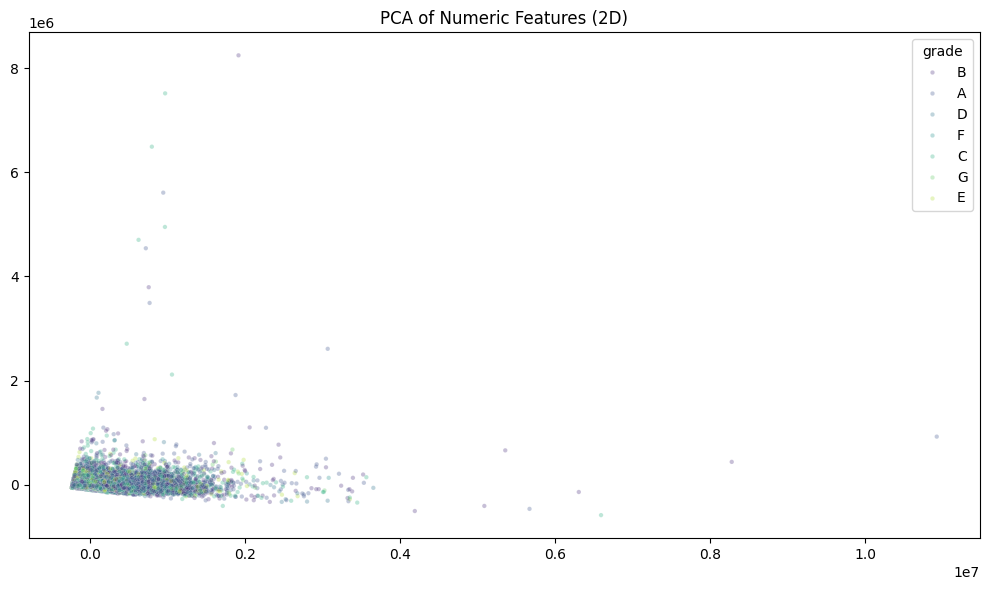

In [5]:
# PCA visualization
X_numeric = df.select_dtypes(include=[np.number]).fillna(0)
X_pca = PCA(n_components=2).fit_transform(X_numeric)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df["grade"], palette="viridis", alpha=0.3, s=10)
plt.title("PCA of Numeric Features (2D)")
plt.tight_layout()
plt.show()

## 2. ML Models

The ML pipeline uses all the data with `GridSearchCV` (3-fold stratified CV).

In [6]:
#Prepare ML data (loads, engineers, builds preprocessor)
# X_ml, y_ml, col_lists, preprocessor, global_scaler, le_ml = prepare_ml_data_test(TRAIN_CSV)
# print(f"\nML data ready: X={X_ml.shape}, y={y_ml.shape}")

X_raw, y_raw, fe_instance, prep_instance, le = prepare_ml_data(TRAIN_CSV)
print("X_raw shape:", X_raw.shape)
X_raw.head()

Data Loaded: (148301, 144). Returned raw X, y and unfitted preprocessors.
X_raw shape: (148301, 144)


,loan_contract_approved_amount,loan_portfolio_total_funded,investor_side_funded_amount,loan_contract_term_months,loan_contract_interest_rate,loan_payment_installments_count,borrower_profile_employment_length,borrower_housing_ownership_status,borrower_income_annual,borrower_income_verification_status,...,hardship_payoff_balance,hardship_last_payment_amount_total,disbursement_method_type,debt_settlement_flag_indicator,debt_settlement_flag_date,settlement_status_label,settlement_date,settlement_amount_total,settlement_percentage,settlement_term_months
0,12000.0,11819.212488,12000.000000,36 months,12.806304,395.66,10+ years,rent,40000.0,source verified,...,NaN,NaN,cash,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10000.0,10683.410001,10023.226279,36 months,7.890000,312.86,2 years,rent,NaN,not verified,...,NaN,NaN,cash,n,NaN,NaN,NaN,NaN,NaN,NaN
2,7000.0,7000.000000,5989.447426,36 months,18.558177,253.04,8 years,mortgage,120000.0,source verified,...,NaN,NaN,cash,n,NaN,NaN,NaN,NaN,NaN,NaN
3,35000.0,35000.000000,35000.000000,60 months,22.950000,985.67,NaN,mortgage,99588.0,verified,...,NaN,NaN,cash,n,NaN,NaN,NaN,NaN,NaN,NaN
4,2400.0,2437.596602,2400.000000,36 months,13.990000,82.02,2 years,rent,37000.0,source verified,...,NaN,NaN,cash,n,NaN,NaN,NaN,NaN,NaN,NaN


### 2.1 Random Forest

In [7]:
# Hyperparameters — edit here
rf_param_grid = {
    "classifier__n_estimators": [300],
    "classifier__max_depth": [None],
    "classifier__min_samples_split": [8],
    "classifier__min_samples_leaf": [1],
    "classifier__max_features": [0.3],
}

#gs_rf = train_random_forest(X_ml, y_ml, preprocessor, param_grid=rf_param_grid)

gs_rf = train_random_forest(
    X=X_raw, 
    y=y_raw, 
    feature_engineer=fe_instance, 
    preprocessor=prep_instance, 
    param_grid=rf_param_grid,
    cv=3
)

Starting RF GridSearch...
Fitting 3 folds for each of 1 candidates, totalling 3 fits


/Users/ma3ti/miniconda3/envs/loan-risk/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Users/ma3ti/miniconda3/envs/loan-risk/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Users/ma3ti/miniconda3/envs/loan-risk/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refr

RF GridSearch complete.


In [8]:
#Save & inspect (separate cell — re-run without retraining)
try:
    #save_model(gs_rf.best_estimator_, "rf")
    save_split_model(gs_rf, "rf")
except Exception as e:
    print(f"Error saving model: {e}")

print_grid_results(gs_rf, "Random Forest")

[RF] Saved Successfully:
  Preprocessor: models/rf_preprocessor.pkl
  Classifier:   models/rf_classifier.pkl

  Random Forest — Best GridSearch Results
  Best Params: {'classifier__max_depth': None, 'classifier__max_features': 0.3, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 8, 'classifier__n_estimators': 300}

  accuracy                 : 0.9651 ± 0.0010
  balanced_accuracy        : 0.9550 ± 0.0016
  f1_weighted              : 0.9651 ± 0.0010
  f1_macro                 : 0.9566 ± 0.0017



Saved: ./models/images/rf_fi.png


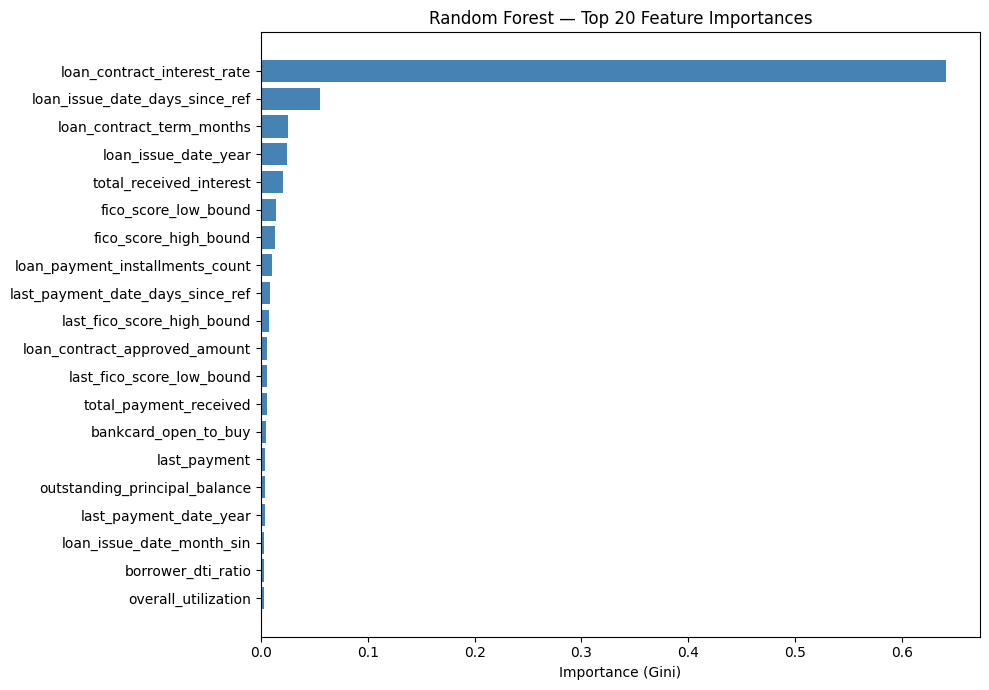

In [12]:
plot_rf_feature_importances(gs_rf, top_k=20, save_path=os.path.join(MODEL_DIR + "/images", "rf_fi.png"))

In [10]:
# 1. Retrieve the fitted pipeline from the GridSearch result
best_pipe = gs_rf.best_estimator_

# Access the specific steps by their names ('engineer' and 'preprocessor')
step_engineer = best_pipe.named_steps["engineer"]
step_preprocessor = best_pipe.named_steps["preprocessor"]

# ---------------------------------------------------------
# Check 1: Output of Feature Engineer
# ---------------------------------------------------------
# We transform X_raw using the fitted engineer
X_engineered = step_engineer.transform(X_raw)

print(f"1. Raw Input Shape:             {X_raw.shape}")
print(f"2. After Feature Engineering:   {X_engineered.shape}")
print(f"   (Columns added/dropped: {X_engineered.shape[1] - X_raw.shape[1]})")

# Optional: Look at the columns to see what changed
# print(X_engineered.columns.tolist())

# ---------------------------------------------------------
# Check 2: Output of Preprocessor (Scaling + OneHot)
# ---------------------------------------------------------
# Pass the engineered data into the preprocessor
X_final = step_preprocessor.transform(X_engineered)

print(f"3. After Preprocessing (Final): {X_final.shape}")
print(f"   (Total features for Model: {X_final.shape[1]})")

1. Raw Input Shape:             (148301, 144)
2. After Feature Engineering:   (148301, 126)
   (Columns added/dropped: -18)
3. After Preprocessing (Final): (148301, 1111)
   (Total features for Model: 1111)


### 2.2 KNN

In [ ]:
knn_param_grid = {
    "pca__n_components": [30],
    "preprocessor__scaler": [StandardScaler()],
    "classifier__n_neighbors": [30],
    "classifier__weights": ["distance"],
    "classifier__p": [2],
}

gs_knn = train_knn(
    X=X_raw, 
    y=y_raw, 
    feature_engineer=fe_instance, 
    preprocessor=prep_instance, 
    param_grid=knn_param_grid,
    cv=3
)

In [ ]:
try:
    #save_model(gs_knn.best_estimator_, "knn")
    save_split_model(gs_knn, "knn")
except Exception as e:
    print(f"Error saving model: {e}")

print_grid_results(gs_knn, "KNN")

### 2.3 SVM

In [ ]:
svm_param_grid = {
    "preprocessor__scaler": [StandardScaler()],
    #"classifier__C": [ 100, 300, 500],
    "classifier__C": [100],
    "classifier__kernel": ["rbf"],
    "classifier__gamma": ["scale"],
    "classifier__max_iter": [1000],
}

#gs_svm = train_svm(X_ml, y_ml, preprocessor, global_scaler, param_grid=svm_param_grid)
gs_svm = train_svm(
    X=X_raw, 
    y=y_raw, 
    feature_engineer=fe_instance, 
    preprocessor=prep_instance, 
    param_grid=svm_param_grid,
    cv=3
)

In [ ]:
try:
    #save_model(gs_svm.best_estimator_, "svm")
    save_split_model(gs_svm, "svm")
except Exception as e:
    print(f"Error saving model: {e}")
    
print_grid_results(gs_svm, "SVM")

## 3. Deep Learning Models

DL uses an explicit train/val/test split. Preprocessing is fit on train only.

In [ ]:
# 1. Load Data
import pandas as pd
import pickle
import shutil
import numpy as np
from data_processing import FFNNPreprocessor # Ensure this imports your latest class

# Load raw training data (adjust path if necessary)
df_full = pd.read_csv("data/train.csv") 
X_full = df_full.drop(columns=["grade"])
y_full = df_full["grade"]

# Re-create the split to get the exact Training set used before
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y_full)

# Split 1 (Test)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_full, y_encoded, test_size=0.10, stratify=y_encoded, random_state=42
)

# Split 2 (Val) - relative size to get 10% total
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.10/0.90, stratify=y_temp, random_state=42
)

# 2. Fit the Preprocessor (In the CURRENT 1.7.2 Environment)
print("Re-fitting FFNNPreprocessor...")
dl_pipeline = FFNNPreprocessor()
dl_pipeline.fit(X_train)

# 3. Save it
import os
os.makedirs("models", exist_ok=True)

print("Saving updated preprocessor...")
with open("models/ffnn_preprocessor.pkl", "wb") as f:
    pickle.dump(dl_pipeline, f)

# 4. Duplicate for TabNet and TabTransformer
shutil.copy("models/ffnn_preprocessor.pkl", "models/tabnet_preprocessor.pkl")
shutil.copy("models/ffnn_preprocessor.pkl", "models/tabtransformer_preprocessor.pkl")

print("Success! Preprocessors updated to Scikit-Learn 1.7.2 format.")

In [ ]:
# Prepare DL data
dl_data_raw = prepare_dl_data(TRAIN_CSV, val_size=0.10, test_size=0.10)

In [ ]:
print(f"\nDL data shapes:")
print(f"  X_train: {dl_data_raw['X_train'].shape}")
print(f"  X_val  : {dl_data_raw['X_val'].shape}")
print(f"  X_test : {dl_data_raw['X_test'].shape}")
print(f"  Num cols: {dl_data_raw['num_num_cols']}, Cat cols: {dl_data_raw['num_cat_cols']}")
print(f"  Classes : {dl_data_raw['num_classes']}")
#print(f"  Cat cardinalities: {dl_data['cat_cardinalities']}")
print(f"  Feature names ({len(dl_data_raw['feature_names'])}): {dl_data_raw['feature_names'][:10]}...")

In [ ]:
# 1. Instantiate the class
dl_pipeline = FFNNPreprocessor()

print("Fitting DL Preprocessor...")
dl_pipeline.fit(dl_data_raw['X_train']) # X_train_raw is your dataframe before any processing

# 3. Save it
with open("models/ffnn_preprocessor.pkl", "wb") as f:
    pickle.dump(dl_pipeline, f)
print("Saved models/ffnn_preprocessor.pkl")

In [ ]:
X_train_np = dl_pipeline.transform(dl_data_raw['X_train'])
X_val_np   = dl_pipeline.transform(dl_data_raw['X_val'])
X_test_np  = dl_pipeline.transform(dl_data_raw['X_test'])

print(f"\nDL data shapes:")
print(f"  X_train: {X_train_np.shape}")
print(f"  X_val  : {X_val_np.shape}")
print(f"  X_test : {X_test_np.shape}")

meta = dl_pipeline.get_metadata()
print(f"Metadata Extracted: {meta['num_num_cols']} numeric, {meta['num_cat_cols']} categorical")

In [ ]:
# Class weights (shared across all DL models)
class_weights_array = get_class_weights(dl_data_raw["y_train"])
class_weights_dict = get_class_weights_dict(dl_data_raw["y_train"])
class_names = [f"Grade {c}" for c in dl_data_raw["label_encoder"].classes_]
feature_names = dl_data_raw["feature_names"]

print(f"Class weights: {dict(enumerate(class_weights_array))}")
print(f"Class names: {class_names}")
print(f"Feature names: {len(feature_names)} total")

for name, y in [("Train", dl_data_raw["y_train"]),
                ("Val",   dl_data_raw["y_val"]),
                ("Test",  dl_data_raw["y_test"])]:
    unique, counts = np.unique(y, return_counts=True)
    pcts = counts / counts.sum() * 100
    print(f"{name:5s}: {dict(zip(unique, [f'{p:.1f}%' for p in pcts]))}")

### 3.1 TabNet

In [ ]:
# ── TabNet Hyperparameters (edit here) ──
TABNET_HP = dict(
    # Architecture
    n_d=64,
    n_a=64,
    n_steps=3,
    gamma=1.3,
    n_independent=2,
    n_shared=2,
    cat_emb_dim=10,
    # Optimization
    lr=0.02,
    scheduler_step_size=20,
    scheduler_gamma=0.7,
    # Regularization
    lambda_sparse=1e-5,
    momentum=0.02,
    mask_type="entmax",
    # Training
    max_epochs=200,
    patience=20,
    batch_size=1024,
    virtual_batch_size=128,
)

In [ ]:
# Build TabNet
tabnet_model = build_tabnet_classifier(
    cat_indices=meta["cat_indices"],
    cat_cardinalities=meta["cat_cardinalities"],
    device=DEVICE,
    seed=SEED,
    n_d=TABNET_HP["n_d"],
    n_a=TABNET_HP["n_a"],
    n_steps=TABNET_HP["n_steps"],
    gamma=TABNET_HP["gamma"],
    n_independent=TABNET_HP["n_independent"],
    n_shared=TABNET_HP["n_shared"],
    cat_emb_dim=TABNET_HP["cat_emb_dim"],
    lr=TABNET_HP["lr"],
    scheduler_step_size=TABNET_HP["scheduler_step_size"],
    scheduler_gamma=TABNET_HP["scheduler_gamma"],
    lambda_sparse=TABNET_HP["lambda_sparse"],
    momentum=TABNET_HP["momentum"],
    mask_type=TABNET_HP["mask_type"],
)

In [ ]:
# Train TabNet
tabnet_model = train_tabnet(
    model=tabnet_model,
    X_train=X_train_np,
    y_train=dl_data_raw["y_train"],
    X_val=X_val_np,
    y_val=dl_data_raw["y_val"],
    max_epochs=TABNET_HP["max_epochs"],
    patience=TABNET_HP["patience"],
    batch_size=TABNET_HP["batch_size"],
    virtual_batch_size=TABNET_HP["virtual_batch_size"],
    class_weights=class_weights_dict,
)

In [ ]:
# Plot TabNet training history
tabnet_train_loss = tabnet_model.history["loss"]
tabnet_val_loss = tabnet_model.history["val_0_logloss"]
plot_losses(tabnet_train_loss, tabnet_val_loss, title="TabNet: Training vs Validation Loss")

In [ ]:

y_pred_tabnet = tabnet_model.predict(X_test_np)
y_test = dl_data_raw["y_test"]

print(f"\n{'='*50}")
print(f"  TabNet Test Set Evaluation")
print(f"{'='*50}")
print(f"  Accuracy          : {accuracy_score(y_test, y_pred_tabnet):.4f}")
print(f"  Balanced Accuracy : {balanced_accuracy_score(y_test, y_pred_tabnet):.4f}")
print(f"  F1 (weighted)     : {f1_score(y_test, y_pred_tabnet, average='weighted'):.4f}")
print(f"  F1 (macro)        : {f1_score(y_test, y_pred_tabnet, average='macro'):.4f}")
print()
print(classification_report(y_test, y_pred_tabnet, target_names=class_names))

plot_confusion_matrix(y_test, y_pred_tabnet, class_names=class_names, title="TabNet Confusion Matrix")

In [ ]:
# 1. Extract the feature names from the internal ColumnTransformer
# The ColumnTransformer stores the columns used for each step in .transformers_
# structure: [(name, transformer, columns), ...]

ct = dl_pipeline.dl_preprocessor_

# Index 0 is the "num" pipeline (Numerical)
# Index 1 is the "cat" pipeline (Categorical)
num_cols = ct.transformers_[0][2]
cat_cols = ct.transformers_[1][2]

# The output array is always [Numerical features | Categorical features]
correct_feature_names = num_cols + cat_cols

print(f"Correct feature count: {len(correct_feature_names)}") 
# 2. Now plot with the correct names
plot_feature_importances(
    importances=tabnet_model.feature_importances_,
    feature_names=correct_feature_names,
    top_k=20,
    title="TabNet — Feature Importances",
)

In [ ]:
#tabnet_save_path = os.path.join(MODEL_DIR, "best_tabnet")
#tabnet_model.save_model(tabnet_save_path)
#print(f"TabNet model saved to {tabnet_save_path}")

with open("models/tabnet_classifier.pkl", "wb") as f:
    pickle.dump(tabnet_model, f)

### 3.2 Feed-Forward Neural Network (FFNN)

In [ ]:
FFNN_HP = dict(
    # Architecture
    hidden_units=[256, 128, 64],
    dropout_rates=[0.3, 0.05],
    # Training
    num_epochs=300,
    batch_size=256,
    learning_rate=3e-4,
    weight_decay=1e-4,
    patience=25,
    scheduler_patience=5,
    scheduler_factor=0.3,
)

In [ ]:
train_ds = LoanDataset(X_train_np, dl_data_raw["y_train"])
val_ds   = LoanDataset(X_val_np,   dl_data_raw["y_val"])
test_ds  = LoanDataset(X_test_np,  dl_data_raw["y_test"])

train_loader, val_loader, test_loader = create_loaders(
    train_ds, val_ds, test_ds, batch_size=FFNN_HP["batch_size"]
)

print(f"Input dim: {train_ds.num_features}, Output dim: {train_ds.num_classes}")

In [ ]:
fix_random(SEED)

ffnn_model = LoanClassifierFFNN(
    input_dim=train_ds.num_features,
    output_dim=train_ds.num_classes,
    hidden_units=FFNN_HP["hidden_units"],
    dropout_rates=FFNN_HP["dropout_rates"],
).to(DEVICE)

print(ffnn_model)
print(f"Parameters: {sum(p.numel() for p in ffnn_model.parameters()):,}")

In [ ]:
ffnn_model, t_losses, v_losses = train_model(
    model=ffnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=FFNN_HP["num_epochs"],
    patience=FFNN_HP["patience"],
    learning_rate=FFNN_HP["learning_rate"],
    weight_decay=FFNN_HP["weight_decay"],
    scheduler_patience=FFNN_HP["scheduler_patience"],
    scheduler_factor=FFNN_HP["scheduler_factor"],
    class_weights=class_weights_array,
    device=DEVICE,
    save_name="best_ffnn.pkl",
    model_type="standard",
)

plot_losses(t_losses, v_losses, title="FFNN: Training vs Validation Loss")

In [ ]:
ffnn_results = evaluate_model(
    ffnn_model, test_loader, DEVICE,
    class_names=class_names, model_type="standard", set_name="FFNN Test"
)
plot_confusion_matrix(ffnn_results["y_true"], ffnn_results["y_pred"],
                      class_names=class_names, title="FFNN Confusion Matrix")



### 3.3 Tab Transformer

In [ ]:
# ── TabTransformer Hyperparameters (edit here) ──
TABT_HP = dict(
    # Architecture
    dim=8,
    depth=2,
    heads=4,
    attn_dropout=0.5,
    ff_dropout=0.5,
    mlp_hidden_mults=(2, 1),
    # Training
    num_epochs=100,
    batch_size=2048,
    learning_rate=3e-4,
    weight_decay=0.05,
    patience=10,
    max_grad_norm=1.0,
    use_cosine_scheduler=True,
    warmup_epochs=10,
)

In [ ]:
# Build datasets (TabularDataset splits num/cat)
n_num = dl_data_raw["num_num_cols"]

train_ds_tt = TabularDataset(X_train_np, dl_data_raw["y_train"], meta["num_num_cols"])
val_ds_tt   = TabularDataset(X_val_np,   dl_data_raw["y_val"],   meta["num_num_cols"])
test_ds_tt  = TabularDataset(X_test_np,  dl_data_raw["y_test"],  meta["num_num_cols"])

train_loader_tt, val_loader_tt, test_loader_tt = create_loaders(
    train_ds_tt, val_ds_tt, test_ds_tt, batch_size=TABT_HP["batch_size"]
)

print(f"Numeric: {train_ds_tt.n_num}, Categorical: {train_ds_tt.n_cat}")

In [ ]:
# Build & train TabTransformer
fix_random(SEED)

tab_transformer = build_tab_transformer(
    cat_cardinalities=tuple(meta["cat_cardinalities"]),
    num_continuous=meta["num_num_cols"],
    cont_mean_std=meta["cont_mean_std"],
    num_classes=dl_data_raw["num_classes"],
    dim=TABT_HP["dim"],
    depth=TABT_HP["depth"],
    heads=TABT_HP["heads"],
    attn_dropout=TABT_HP["attn_dropout"],
    ff_dropout=TABT_HP["ff_dropout"],
    mlp_hidden_mults=TABT_HP["mlp_hidden_mults"],
    device=DEVICE,
)

print(tab_transformer)
print(f"Parameters: {sum(p.numel() for p in tab_transformer.parameters()):,}")

In [ ]:
tab_transformer, t_losses_tt, v_losses_tt = train_model(
    model=tab_transformer,
    train_loader=train_loader_tt,
    val_loader=val_loader_tt,
    num_epochs=TABT_HP["num_epochs"],
    patience=TABT_HP["patience"],
    learning_rate=TABT_HP["learning_rate"],
    weight_decay=TABT_HP["weight_decay"],
    #scheduler_patience=TABT_HP["scheduler_patience"],
    #scheduler_factor=TABT_HP["scheduler_factor"],
    class_weights=class_weights_array,
    device=DEVICE,
    save_name="best_tab_transformer.pkl",
    model_type="tab_transformer",
    max_grad_norm=TABT_HP.get("max_grad_norm"),
    use_cosine_scheduler=TABT_HP.get("use_cosine_scheduler", False),
    warmup_epochs=TABT_HP.get("warmup_epochs", 0)
)

plot_losses(t_losses_tt, v_losses_tt, title="TabTransformer: Training vs Validation Loss")

In [ ]:
# Evaluate TabTransformer
tt_results = evaluate_model(
    tab_transformer, test_loader_tt, DEVICE,
    class_names=class_names, model_type="tab_transformer", set_name="TabTransformer Test"
)
plot_confusion_matrix(tt_results["y_true"], tt_results["y_pred"],
                      class_names=class_names, title="TabTransformer Confusion Matrix")

In [ ]:
# 1. Import the wrapper FROM the file (so pickle knows where it lives)
from data_processing import TabTransformerInferenceWrapper
import pickle

# 2. Load your best trained weights
# (Assuming train_model saved "best_tab_transformer.pkl")
with open("models/best_tab_transformer.pkl", "rb") as f:
    best_tt_model = pickle.load(f)

# 3. Get the number of numeric columns
# (You have this in dl_data or meta)
n_num = meta["num_num_cols"] 

# 4. Wrap the model
inference_model = TabTransformerInferenceWrapper(best_tt_model, n_num)
inference_model.eval()
inference_model.cpu() # Essential for portability

# 5. Save the WRAPPER as the final classifier
with open("models/tabtransformer_classifier.pkl", "wb") as f:
    pickle.dump(inference_model, f)

print("Saved Wrapper Model to models/tabtransformer_classifier.pkl")

# 4. Overall Comparison

In [ ]:
print(f"\n{'='*60}")
print(f"  RESULTS COMPARISON")
print(f"{'='*60}")
print(f"{'Model':<20} {'Accuracy':>10} {'Bal Acc':>10} {'F1 macro':>10}")
print(f"{'-'*60}")

# ML models
for name, gs in [("Random Forest", gs_rf), ("KNN", gs_knn), ("SVM", gs_svm)]:
    idx = gs.best_index_
    acc = gs.cv_results_["mean_test_accuracy"][idx]
    bal = gs.cv_results_["mean_test_balanced_accuracy"][idx]
    f1m = gs.cv_results_["mean_test_f1_macro"][idx]
    print(f"{name:<20} {acc:>10.4f} {bal:>10.4f} {f1m:>10.4f}  (CV)")

# DL models 
print(f"{'FFNN':<20} {ffnn_results['accuracy']:>10.4f} {ffnn_results['balanced_accuracy']:>10.4f} {ffnn_results['f1_macro']:>10.4f}  (test)")

tabnet_acc = accuracy_score(y_test, y_pred_tabnet)
tabnet_bal = balanced_accuracy_score(y_test, y_pred_tabnet)
tabnet_f1m = f1_score(y_test, y_pred_tabnet, average="macro")
print(f"{'TabNet':<20} {tabnet_acc:>10.4f} {tabnet_bal:>10.4f} {tabnet_f1m:>10.4f}  (test)")

print(f"{'TabTransformer':<20} {tt_results['accuracy']:>10.4f} {tt_results['balanced_accuracy']:>10.4f} {tt_results['f1_macro']:>10.4f}  (test)")